In [15]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
import yastn
from yastn.tn import mps

In [16]:
Nas = [(256, 0.125), (512, 0.0625), (512, 0.125)]
dEs = [-650.9475000080395 + 652.4669084578825,  -2605.370934773492 + 2606.876134316029, -1304.8464455965538 + 1306.3635588292507]
g = 1
m = 0.5
sg2 = 0.25
x0 = 1.5

In [17]:
probs = {(N, a): np.load(f"./results_fermions/probs_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
probs_gs = {(N, a): np.load(f"./results_fermions/probs_gs_gauss_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}

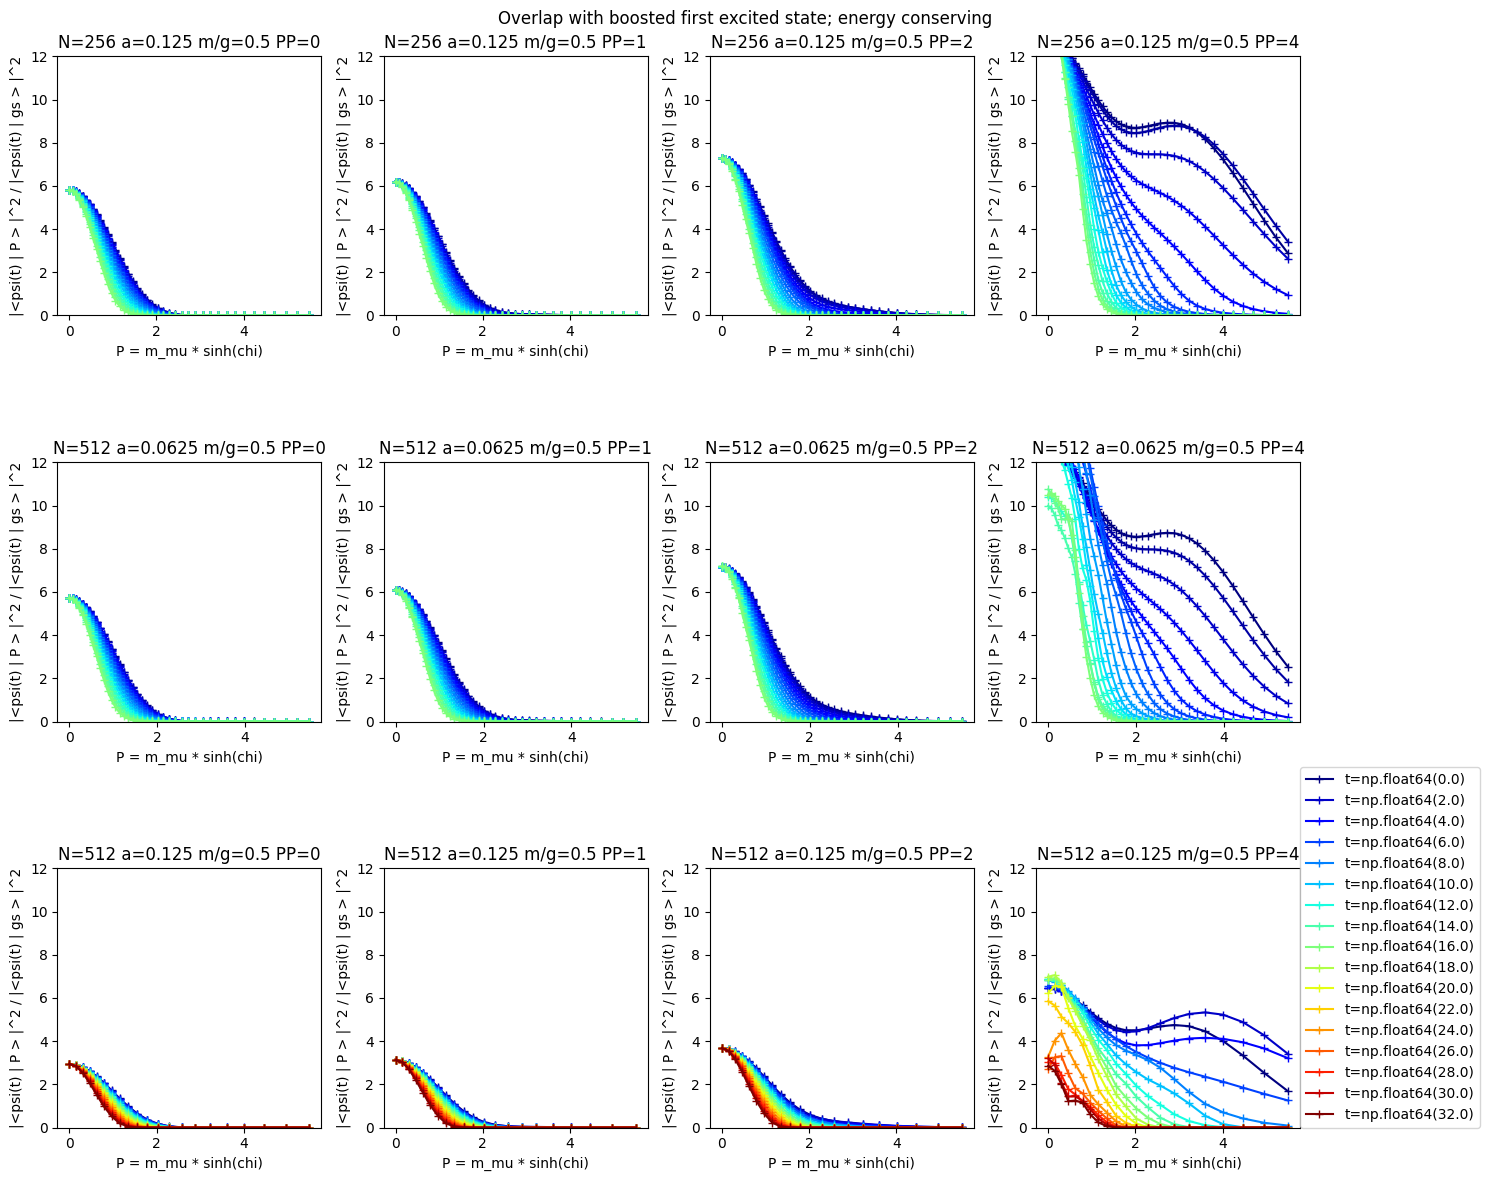

In [21]:
cm = plt.cm.jet
Ps = [0, 1, 2, 4]
fig, axs = plt.subplots(len(Nas), len(Ps))
fig.set_size_inches(len(Nas) * 5, len(Ps) * 3)
for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  chis = sorted(set(chi for t, PP, D, chi in probs[N, a]))
  # Ps = sorted(set(PP for t, PP, D, chi in probs[N, a]))
  ts = sorted(set(t for t, PP, D, chi in probs[N, a]))
  Ds = sorted(set(D for t, PP, D, chi in probs[N, a]))
  Ds = [512]
  #
  for jj, PP in enumerate(Ps):
      for D in Ds:
        for t in ts:
          pr = [probs[N, a][t, PP, D, chi] / probs_gs[N, a][t, PP, D] for chi in chis]
          P = np.sinh(chis) * (dE)
          sym = '-+' if D == Ds[0] else '-o'
          line, = axs[ii, jj].plot(P, pr, sym, color = cm(t / 32))
          if D == Ds[0]:
            line.set_label(f"{t=}")
      axs[ii,jj].set_xlabel('P = m_mu * sinh(chi)')
      axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
      #axs[ii,jj].set_xlim([0, 2])
      axs[ii,jj].set_title(f"{N=} {a=} {m/g=} {PP=}")
      axs[ii,jj].set_ylim([0, 12])
fig.suptitle("Overlap with boosted first excited state; energy conserving")
axs[-1, -1].legend(loc=(1, 0))
plt.tight_layout()


In [19]:
PPs = np.linspace(0, 3, 25)
probs_R = {(N, a): np.load(f"./results_fermions/probs_gauss_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}


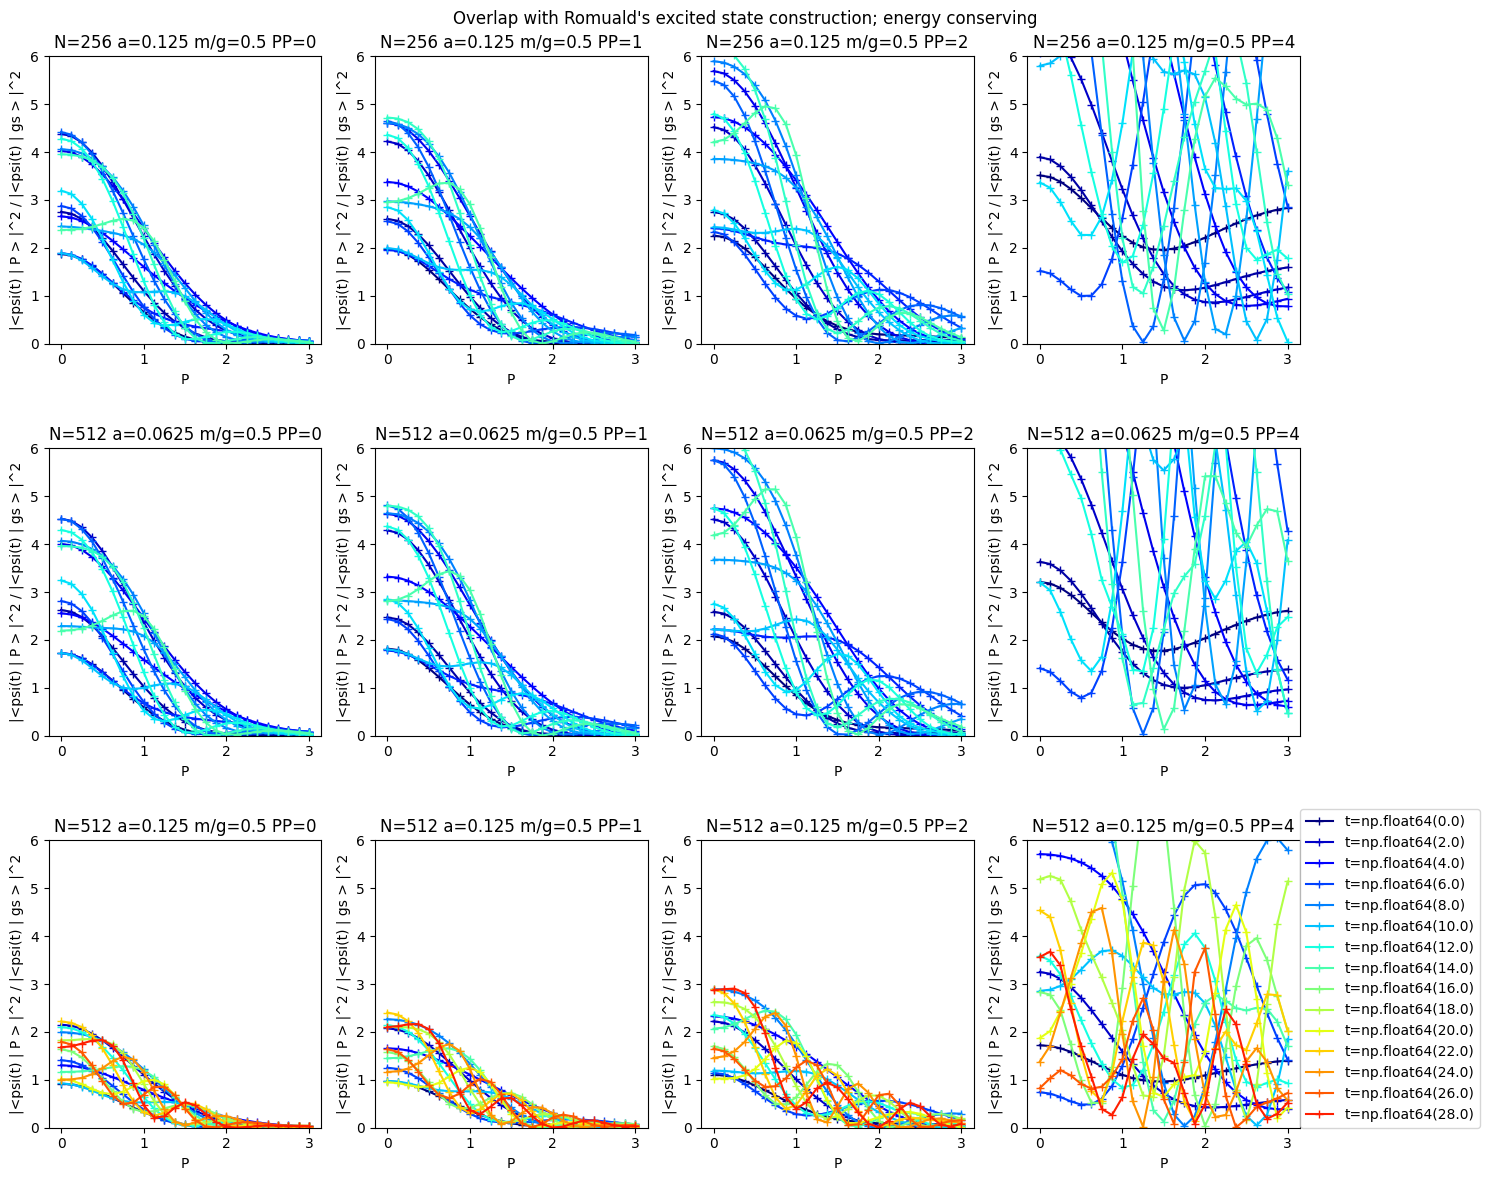

In [20]:
cm = plt.cm.jet
Ps = [0, 1, 2, 4]

PPs = np.linspace(0, 3, 25)

fig, axs = plt.subplots(len(Nas), len(Ps))
fig.set_size_inches(len(Nas) * 5, len(Ps) * 3)
for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  ts = sorted(set(t for t, PP, D, chi in probs[N, a]))
  Ds = sorted(set(D for t, PP, D, chi in probs[N, a]))
  Ds = [512]
  #
  for jj, PP in enumerate(Ps):
      for D in Ds:
        for t in ts[:-2]:
          pr = [probs_R[N, a][t, PP, D, P] / probs_gs[N, a][t, PP, D] for P in PPs]
          sym = '-+' if D == Ds[0] else '-o'
          line, = axs[ii, jj].plot(PPs, pr, sym, color = cm(t / 32))
          if D == Ds[0]:
            line.set_label(f"{t=}")
      axs[ii,jj].set_xlabel('P')
      axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
      #axs[ii,jj].set_xlim([0, 2])
      axs[ii,jj].set_title(f"{N=} {a=} {m/g=} {PP=}")
      axs[ii,jj].set_ylim([0, 6])

fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

axs[-1, -1].legend(loc=(1, 0))
plt.tight_layout()
